In [14]:
# =========================
# TOKENIZER + INPUT
# =========================

import torch
import torch.nn as nn
import torch.nn.functional as F
import tiktoken

tokenizer = tiktoken.get_encoding("gpt2")

batch = []

txt1 = "Every effort moves you"
txt2 = "Every day holds a"

batch.append(torch.tensor(tokenizer.encode(txt1)))
batch.append(torch.tensor(tokenizer.encode(txt2)))

# ✅ FIX HERE
# stack() joins multiple tensors into one batch tensor
# dim=0 means create batch dimension at first position
batch = torch.stack(batch, dim=0)

print(batch.shape)  # should be (2, seq_len)


# =========================
# CONFIG
# =========================

GPT_CONFIG_124M = {
    "vocab_size": 50257,    # Vocabulary size
    "context_length": 1024, # Context length
    "emb_dim": 264,         # Embedding dimension
    "n_heads": 12,          # Number of attention heads
    "n_layers": 12,         # Number of layers
    "drop_rate": 0.1,       # Dropout rate
    "qkv_bias": False       # Query-Key-Value bias
}

device = "cuda" if torch.cuda.is_available() else "cpu"


# =========================
# MODEL COMPONENTS
# =========================

class MultiHeadAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()

        assert (d_out % num_heads == 0), \
            "d_out must be divisible by num_heads"

        self.d_out = d_out
        self.num_heads = num_heads

        # Reduce the projection dim to match desired output dim
        self.head_dim = d_out // num_heads

        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)

        # Linear layer to combine head outputs
        self.out_proj = nn.Linear(d_out, d_out)

        self.dropout = nn.Dropout(dropout)

        # Causal mask:
        # upper triangle = future tokens
        # model should NOT see future words
        self.register_buffer(
            "mask",
            torch.triu(
                torch.ones(context_length, context_length),
                diagonal=1
            )
        )

    def forward(self, x):
        # x shape:
        # (batch, num_tokens, embedding_dim)

        b, num_tokens, d_in = x.shape

        # Shape: (b, num_tokens, d_out)
        keys = self.W_key(x)
        queries = self.W_query(x)
        values = self.W_value(x)

        # =========================================
        # Split into multiple heads
        # =========================================

        # We implicitly split the matrix by adding
        # a `num_heads` dimension

        # Unroll last dim:
        # (b, num_tokens, d_out)
        # ->
        # (b, num_tokens, num_heads, head_dim)

        # view() = split one big vector into multiple heads

        keys = keys.view(
            b,
            num_tokens,
            self.num_heads,
            self.head_dim
        )

        values = values.view(
            b,
            num_tokens,
            self.num_heads,
            self.head_dim
        )

        queries = queries.view(
            b,
            num_tokens,
            self.num_heads,
            self.head_dim
        )

        # =========================================
        # Transpose for attention calculation
        # =========================================

        # (b, num_tokens, num_heads, head_dim)
        # ->
        # (b, num_heads, num_tokens, head_dim)

        keys = keys.transpose(1, 2)
        queries = queries.transpose(1, 2)
        values = values.transpose(1, 2)

        # =========================================
        # Compute Self Attention
        # =========================================

        # Dot product for each head

        attn_scores = queries @ keys.transpose(2, 3)

        # Original mask truncated to current tokens
        # and converted to boolean

        mask_bool = self.mask.bool()[:num_tokens, :num_tokens]

        # Fill future token positions with -inf
        # so softmax makes them zero

        attn_scores.masked_fill_(mask_bool, -torch.inf)

        # =========================================
        # Temperature Scaling
        # =========================================

        # Standard attention scaling:
        # divide by sqrt(head_dim)

        attn_weights = torch.softmax(
            attn_scores / keys.shape[-1] ** 0.5,
            dim=-1
        )

        attn_weights = self.dropout(attn_weights)

        # =========================================
        # Final context vector
        # =========================================

        # Shape:
        # (b, num_tokens, num_heads, head_dim)

        context_vec = (attn_weights @ values).transpose(1, 2)

        # Combine heads:
        # self.d_out = self.num_heads * self.head_dim

        context_vec = context_vec.contiguous().view(
            b,
            num_tokens,
            self.d_out
        )

        # optional projection

        context_vec = self.out_proj(context_vec)

        return context_vec


# =========================
# LAYER NORM
# =========================

class LayerNorm(nn.Module):
    def __init__(self, emb_dim):
        super().__init__()

        self.eps = 1e-5

        # learnable gamma
        self.scale = nn.Parameter(torch.ones(emb_dim))

        # learnable beta
        self.shift = nn.Parameter(torch.zeros(emb_dim))

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)

        var = x.var(
            dim=-1,
            keepdim=True,
            unbiased=False
        )

        return (
            self.scale
            * (x - mean)
            / torch.sqrt(var + self.eps)
            + self.shift
        )


# =========================
# GELU ACTIVATION
# =========================

class GELU(nn.Module):
    def forward(self, x):
        return 0.5 * x * (
            1 + torch.tanh(
                torch.sqrt(torch.tensor(2.0 / torch.pi))
                * (x + 0.044715 * x ** 3)
            )
        )


# =========================
# FEED FORWARD NETWORK
# =========================

class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(
                cfg["emb_dim"],
                4 * cfg["emb_dim"]
            ),
            GELU(),
            nn.Linear(
                4 * cfg["emb_dim"],
                cfg["emb_dim"]
            )
        )

    def forward(self, x):
        return self.net(x)


# =========================
# TRANSFORMER BLOCK
# =========================

class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()

        self.att = MultiHeadAttention(
            cfg["emb_dim"],
            cfg["emb_dim"],
            cfg["context_length"],
            cfg["drop_rate"],
            cfg["n_heads"],
            cfg["qkv_bias"]
        )

        self.ff = FeedForward(cfg)

        self.norm1 = LayerNorm(cfg["emb_dim"])
        self.norm2 = LayerNorm(cfg["emb_dim"])

        self.drop = nn.Dropout(cfg["drop_rate"])

    def forward(self, x):
        # Residual connection + attention
        x = x + self.drop(
            self.att(self.norm1(x))
        )

        # Residual connection + feedforward
        x = x + self.drop(
            self.ff(self.norm2(x))
        )

        return x


# =========================
# GPT MODEL
# =========================

class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()

        self.tok_emb = nn.Embedding(
            cfg["vocab_size"],
            cfg["emb_dim"]
        )

        self.pos_emb = nn.Embedding(
            cfg["context_length"],
            cfg["emb_dim"]
        )

        self.drop = nn.Dropout(cfg["drop_rate"])

        self.blocks = nn.Sequential(
            *[
                TransformerBlock(cfg)
                for _ in range(cfg["n_layers"])
            ]
        )

        self.norm = LayerNorm(cfg["emb_dim"])

        self.head = nn.Linear(
            cfg["emb_dim"],
            cfg["vocab_size"],
            bias=False
        )

    def forward(self, idx):
        B, T = idx.shape

        tok = self.tok_emb(idx)

        # positional embedding
        pos = self.pos_emb(
            torch.arange(T, device=idx.device)
        )

        x = self.drop(tok + pos)

        x = self.blocks(x)

        x = self.norm(x)

        return self.head(x)




torch.Size([2, 4])


In [17]:
# =========================
# TEXT GENERATION
# WITH TEMPERATURE SCALING
# =========================

def generate_text_simple_with_temperature(
    model,
    idx,
    max_new_tokens,
    context_size,
    temperature=1.0
):
    # idx is:
    # (batch, n_tokens)
    # array of token indices

    for _ in range(max_new_tokens):

        # Crop current context if it exceeds
        # the supported context size

        # Example:
        # if model supports only 5 tokens
        # and current size is 10

        # then we keep only last 5 tokens

        # idx[:, -context_size:]
        # first colon = all batches

        # -context_size means:
        # if context_size = 5
        # then take last 5 tokens

        idx_cond = idx[:, -context_size:]

        # Get predictions

        # PyTorch uses autograd to track
        # operations for backpropagation

        with torch.no_grad():
            logits = model(idx_cond)

        # Focus only on last time step

        # (batch, n_tokens, vocab_size)
        # becomes
        # (batch, vocab_size)

        # Model predicts for EVERY position

        # but we only need next-word prediction

        # so we capture last token only

        logits = logits[:, -1, :]

        # =====================================
        # TEMPERATURE SCALING
        # =====================================

        # Formula:
        # softmax(logits / temperature)

        # low temp  -> safer output
        # high temp -> creative output

        logits = logits / temperature

        # Apply softmax to get probabilities

        probas = torch.softmax(
            logits,
            dim=-1
        )

        # IMPORTANT:
        # use multinomial instead of argmax

        # argmax:
        # always same word

        # multinomial:
        # sample based on probability

        idx_next = torch.multinomial(
            probas,
            num_samples=1
        )

        # Append sampled index
        # to running sequence

        idx = torch.cat(
            (idx, idx_next),
            dim=1
        )

    return idx




In [18]:
# =========================
# RUN MODEL
# =========================

torch.manual_seed(123)

model = GPTModel(GPT_CONFIG_124M)
model.eval()

batch = batch.to(device)
model.to(device)

out = generate_text_simple_with_temperature(
    model=model,
    idx=batch,
    max_new_tokens=10,
    context_size=GPT_CONFIG_124M["context_length"],
    temperature=0.8
)

print("\nGenerated Token IDs:\n")
print(out)

print("\nDecoded Output:\n")

for row in out:
    print(tokenizer.decode(row.tolist()))


Generated Token IDs:

tensor([[ 6109,  3626,  6100,   345,  2609, 31104, 17183, 19435, 31557, 21050,
         24173, 19337, 32738, 21935],
        [ 6109,  1110,  6622,   257, 17602,  8588, 46381, 35443, 43717, 48523,
         17884, 11969, 26713, 10097]])

Decoded Output:

Every effort moves you charg Copenhagenotyp insects tv flooded beverages shallow fuse extinction
Every day holds atx possessicksonPoliticalVERSIONHerm rebuild attending gamer----------------------------------------------------------------


### DECODING STRATEGY 2: Top-k sampling

<div class="alert alert-block alert-success">

In the previous section, we implemented a probabilistic sampling approach coupled with
temperature scaling to increase the diversity of the outputs. 

We saw that higher
temperature values result in more uniformly distributed next-token probabilities, which
result in more diverse outputs as it reduces the likelihood of the model repeatedly selecting
the most probable token. 

This method allows for exploring less likely but potentially more
interesting and creative paths in the generation process. 

However, One downside of this
approach is that it sometimes leads to grammatically incorrect or completely nonsensical
outputs such as "every effort moves you pizza".
</div>

<div class="alert alert-block alert-success">

In this section, we introduce another concept called top-k sampling, which, when
combined with probabilistic sampling and temperature scaling, can improve the text
generation results.

In top-k sampling, we can restrict the sampled tokens to the top-k most likely tokens
and exclude all other tokens from the selection process by masking their probability scores.
    
</div>

### DECODING STRATEGY 1: TEMPERATURE SCALING

<div class="alert alert-block alert-success">

Previously, inside the generate_text_simple function, we always sampled the token
with the highest probability as the next token using torch.argmax, also known as greedy
decoding. 

To generate text with more variety, we can replace the argmax with a function
that samples from a probability distribution (here, the probability scores the LLM generates
for each vocabulary entry at each token generation step).

</div>

<div class="alert alert-block alert-success">

To illustrate the probabilistic sampling with a concrete example, let's briefly discuss the
next-token generation process using a very small vocabulary for illustration purposes:

</div>

In [21]:
vocab = { 
    "closer": 0,
    "every": 1, 
    "effort": 2, 
    "forward": 3,
    "inches": 4,
    "moves": 5, 
    "pizza": 6,
    "toward": 7,
    "you": 8,
}

print("vocab", vocab)

inverse_vocab = {v: k for k, v in vocab.items()}

print("inverse_vocab", inverse_vocab)

vocab {'closer': 0, 'every': 1, 'effort': 2, 'forward': 3, 'inches': 4, 'moves': 5, 'pizza': 6, 'toward': 7, 'you': 8}
inverse_vocab {0: 'closer', 1: 'every', 2: 'effort', 3: 'forward', 4: 'inches', 5: 'moves', 6: 'pizza', 7: 'toward', 8: 'you'}


<div class="alert alert-block alert-success">

Next, assume the LLM is given the start context "every effort moves you" and
generates the following next-token logits:

</div>

In [22]:
next_token_logits = torch.tensor(
[4.51, 0.89, -1.90, 6.75, 1.63, -1.62, -1.89, 6.28, 1.79]
)

next_token_logits2 = next_token_logits/0.1

next_token_logits3 = next_token_logits/5

<div class="alert alert-block alert-success">

As discussed in the previous chapter, inside the generate_text_simple, we convert the
logits into probabilities via the softmax function and obtain the token ID corresponding the
generated token via the argmax function, which we can then map back into text via the
inverse vocabulary:

</div>

In [36]:
probas = torch.softmax(next_token_logits2, dim=0)

print(probas)

tensor([1.8530e-10, 3.5189e-26, 2.6890e-38, 9.9099e-01, 5.7569e-23, 4.4220e-37,
        2.9718e-38, 9.0133e-03, 2.8514e-22])


In [25]:
probas = torch.softmax(next_token_logits, dim=0)

print(probas)

next_token_id = torch.argmax(probas).item()

print(next_token_id)

print(inverse_vocab[next_token_id])

tensor([6.0907e-02, 1.6313e-03, 1.0019e-04, 5.7212e-01, 3.4190e-03, 1.3257e-04,
        1.0120e-04, 3.5758e-01, 4.0122e-03])
3
forward


In [26]:
torch.manual_seed(123)
next_token_id = torch.multinomial(probas, num_samples=1).item()
print(inverse_vocab[next_token_id])

forward


In [27]:
def print_sampled_tokens(probas):
    torch.manual_seed(123) # Manual seed for reproducibility
    sample = [torch.multinomial(probas, num_samples=1).item() for i in range(1_000)]
    sampled_ids = torch.bincount(torch.tensor(sample))
    for i, freq in enumerate(sampled_ids):
        print(f"{freq} x {inverse_vocab[i]}")

print_sampled_tokens(probas)

73 x closer
0 x every
0 x effort
582 x forward
2 x inches
0 x moves
0 x pizza
343 x toward


In [28]:
def softmax_with_temperature(logits, temperature):
    scaled_logits = logits / temperature
    return torch.softmax(scaled_logits, dim=0)

# Temperature values
temperatures = [1, 0.1, 5]  # Original, higher confidence, and lower confidence

# Calculate scaled probabilities
scaled_probas = [softmax_with_temperature(next_token_logits, T) for T in temperatures]

##Multinomial

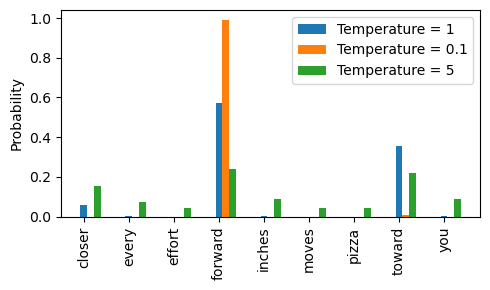

In [30]:
import matplotlib.pyplot as plt
# Plotting
x = torch.arange(len(vocab))
bar_width = 0.15

fig, ax = plt.subplots(figsize=(5, 3))
for i, T in enumerate(temperatures):
    rects = ax.bar(x + i * bar_width, scaled_probas[i], bar_width, label=f'Temperature = {T}')

ax.set_ylabel('Probability')
ax.set_xticks(x)
ax.set_xticklabels(vocab.keys(), rotation=90)
ax.legend()

plt.tight_layout()
plt.savefig("temperature-plot.pdf")
plt.show()

In [37]:
import tiktoken

def text_to_token_ids(text, tokenizer):
    encoded = tokenizer.encode(text, allowed_special={'<|endoftext|>'})
    encoded_tensor = torch.tensor(encoded).unsqueeze(0) # add batch dimension
    return encoded_tensor

def token_ids_to_text(token_ids, tokenizer):
    flat = token_ids.squeeze(0) # remove batch dimension
    return tokenizer.decode(flat.tolist())

start_context = "Every effort moves you"



token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids(start_context, tokenizer),
    max_new_tokens=10,
    context_size=GPT_CONFIG_124M["context_length"]
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves youenegger rendering GroundTempfinalTweetntonbanks rot installation


In [38]:
top_k = 3
top_logits, top_pos = torch.topk(next_token_logits, top_k)
print("Top logits:", top_logits)
print("Top positions:", top_pos)

Top logits: tensor([6.7500, 6.2800, 4.5100])
Top positions: tensor([3, 7, 0])


<div class="alert alert-block alert-success">

Subsequently, we apply PyTorch's where function to set the logit values of tokens that are
below the lowest logit value within our top-3 selection to negative infinity (-inf).
    
</div>

In [39]:
new_logits = torch.where(
    condition=next_token_logits < top_logits[-1],
    input=torch.tensor(float("-inf")), 
    other=next_token_logits
)

print(new_logits)

tensor([4.5100,   -inf,   -inf, 6.7500,   -inf,   -inf,   -inf, 6.2800,   -inf])


<div class="alert alert-block alert-success">

Lastly, let's apply the softmax function to turn these into next-token probabilities:
    
</div>

In [40]:
topk_probas = torch.softmax(new_logits, dim=0)
print(topk_probas)

tensor([0.0615, 0.0000, 0.0000, 0.5775, 0.0000, 0.0000, 0.0000, 0.3610, 0.0000])


### Merge Temperature Scaling and Top-k sampling

<div class="alert alert-block alert-success">

We can now apply the temperature scaling and multinomial function for probabilistic
sampling introduced in the previous section to select the next token among these 3 nonzero probability scores to generate the next token. We do this in the next section by
modifying the text generation function.

</div>

<div class="alert alert-block alert-success">

The previous two subsections introduced two concepts to increase the diversity of LLMgenerated text: temperature sampling and top-k sampling. In this section, we combine and
add these concepts to modify the generate_simple function we used to generate text via
the LLM earlier, creating a new generate function:

</div>

<div class="alert alert-block alert-info">

Step 1: For-loop is the same as before: Get logits, and only focus on last time step

Step 2: In this new section, we filter logits with top_k sampling

Step 3: This is the new section where we apply temperature scaling
    
Step 4: Carry out greedy next-token selection as before when temperature scaling is disabled

Step 5: Stop generating early if end-of-sequence token is encountered and eos_id is specified

</div>

In [41]:
def generate(model, idx, max_new_tokens, context_size, temperature=0.0, top_k=None, eos_id=None):

    # For-loop is the same as before: Get logits, and only focus on last time step
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -context_size:]
        with torch.no_grad():
            logits = model(idx_cond)
        logits = logits[:, -1, :]

        # New: Filter logits with top_k sampling
        if top_k is not None:
            # Keep only top_k values
            top_logits, _ = torch.topk(logits, top_k)
            min_val = top_logits[:, -1]
            logits = torch.where(logits < min_val, torch.tensor(float("-inf")).to(logits.device), logits)

        # New: Apply temperature scaling
        if temperature > 0.0:
            logits = logits / temperature

            # Apply softmax to get probabilities
            probs = torch.softmax(logits, dim=-1)  # (batch_size, context_len)

            # Sample from the distribution
            idx_next = torch.multinomial(probs, num_samples=1)  # (batch_size, 1)

        # Otherwise same as before: get idx of the vocab entry with the highest logits value
        else:
            idx_next = torch.argmax(logits, dim=-1, keepdim=True)  # (batch_size, 1)

        if idx_next == eos_id:  # Stop generating early if end-of-sequence token is encountered and eos_id is specified
            break

        # Same as before: append sampled index to the running sequence
        idx = torch.cat((idx, idx_next), dim=1)  # (batch_size, num_tokens+1)

    return idx

<div class="alert alert-block alert-success">

Let's now see this new generate function in action:
</div>

In [42]:
torch.manual_seed(123)

token_ids = generate(
    model=model,
    idx=text_to_token_ids("Every effort moves you", tokenizer),
    max_new_tokens=15,
    context_size=GPT_CONFIG_124M["context_length"],
    top_k=25,
    temperature=1.4
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you listsbuster reunCross troops Vegaitized HuckabeeジAlmost Shrine securely 480 NeurologTexture


<div class="alert alert-block alert-success">

As we can see, the generated text is very different from the one we previously generated
via the generate_simple function at the beginning of section 5.3 ("Every effort moves
you know," was one of the axioms he laid...!"), which was a memorized passage
from the training set.

</div>